<a href="https://colab.research.google.com/github/hadhanushkadesilva-web/AI--Learning/blob/main/gan_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Wed Jun  3 13:59:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
Device: Tesla T4


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Define the image transformation pipeline:
# 1. Convert PIL image → PyTorch tensor (range [0, 1])
# 2. Normalize to range [-1, 1] (better for GAN training with Tanh output)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # mean=0.5, std=0.5 → maps [0,1] → [-1,1]
])

print("Transform pipeline ready.")

Using device: cuda
Transform pipeline ready.


In [2]:
# Download MNIST and apply our transform
# (First run downloads ~10 MB — takes ~5 seconds)
train_dataset = datasets.MNIST(
    root="./data",          # where to save the dataset
    train=True,             # use the training split (60,000 images)
    download=True,          # download if not already present
    transform=transform     # apply our [-1, 1] normalization
)

# Create a DataLoader to fetch images in batches
batch_size = 128
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,           # randomize order each epoch (important!)
    num_workers=2,          # parallel loading
    pin_memory=True         # speeds up CPU→GPU transfer
)

print(f"Total training images: {len(train_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Image shape (single image): {train_dataset[0][0].shape}")
print(f"Pixel value range: [{train_dataset[0][0].min():.2f}, {train_dataset[0][0].max():.2f}]")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.4MB/s]

Total training images: 60000
Batches per epoch: 469
Image shape (single image): torch.Size([1, 28, 28])
Pixel value range: [-1.00, 1.00]


Batch shape: torch.Size([128, 1, 28, 28])


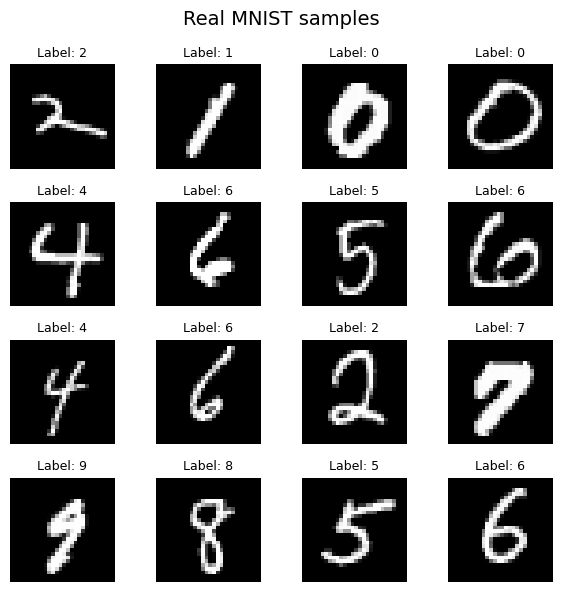

In [3]:
# Get one batch of real images
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")   # should be [128, 1, 28, 28]

# Plot 16 digits in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    # Un-normalize from [-1, 1] back to [0, 1] for display
    img = (images[i].squeeze() + 1) / 2     # squeeze removes channel dim
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}", fontsize=9)
    ax.axis("off")

plt.suptitle("Real MNIST samples", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
class Generator(nn.Module):
    """Generator: takes random noise z, outputs a 28x28 image."""

    def __init__(self, latent_dim=100, image_dim=28*28):
        super().__init__()
        self.latent_dim = latent_dim

        # The network: noise → progressively wider hidden layers → image
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, image_dim),
            nn.Tanh()    # output in [-1, 1] to match normalized real images
        )

    def forward(self, z):
        # z shape: [batch_size, latent_dim]
        img_flat = self.net(z)              # shape: [batch_size, 784]
        img = img_flat.view(-1, 1, 28, 28)  # reshape to image: [B, 1, 28, 28]
        return img


# Instantiate the Generator and move it to GPU
G = Generator().to(device)
print(G)

# Test: generate one random image (untrained — will be noise!)
z_test = torch.randn(1, 100, device=device)   # 1 noise vector
fake_img = G(z_test)
print(f"\nFake image shape: {fake_img.shape}")
print(f"Fake image pixel range: [{fake_img.min().item():.2f}, {fake_img.max().item():.2f}]")

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

Fake image shape: torch.Size([1, 1, 28, 28])
Fake image pixel range: [-0.15, 0.15]


In [5]:
print(f"Total params: {sum(p.numel() for p in G.parameters()):,}")

Total params: 1,486,352


In [6]:
class Discriminator(nn.Module):
    """Discriminator: takes a 28x28 image, outputs probability of being real."""

    def __init__(self, image_dim=28*28):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(image_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()    # output ∈ [0, 1] = probability of being real
        )

    def forward(self, img):
        # img shape: [batch, 1, 28, 28]
        img_flat = img.view(img.size(0), -1)   # flatten to [batch, 784]
        prob = self.net(img_flat)
        return prob


# Instantiate Discriminator and move to GPU
D = Discriminator().to(device)
print(D)

# Test: pass one real image through D
real_img, _ = next(iter(train_loader))
real_img = real_img[:1].to(device)        # take just first image, move to GPU
prob_real = D(real_img)
print(f"\nD's score for one real image: {prob_real.item():.4f}")

# Test: pass one fake (untrained G) image through D
fake_img = G(z_test)                       # reusing z_test from Step 3
prob_fake = D(fake_img)
print(f"D's score for one fake image: {prob_fake.item():.4f}")

print(f"\nTotal D params: {sum(p.numel() for p in D.parameters()):,}")

Discriminator(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

D's score for one real image: 0.5111
D's score for one fake image: 0.5006

Total D params: 1,460,225


In [7]:
# ────────────────────────────────────────────────
# Hyperparameters
# ────────────────────────────────────────────────
latent_dim = 100
lr = 2e-4
beta1 = 0.5     # Adam's first momentum coefficient — 0.5 works better than default 0.9 for GANs

# ────────────────────────────────────────────────
# Loss function and optimizers
# ────────────────────────────────────────────────
criterion = nn.BCELoss()    # Binary Cross-Entropy — for D's classification

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

# Real / fake labels
real_label = 1.0
fake_label = 0.0

# Fixed noise for visualizing progress across epochs
# (same z each time → we can see how G improves on the SAME inputs)
fixed_noise = torch.randn(16, latent_dim, device=device)

print("Hyperparameters, loss, and optimizers ready.")
print(f"  Learning rate: {lr}")
print(f"  Adam beta1: {beta1}")
print(f"  Latent dim: {latent_dim}")


# ────────────────────────────────────────────────
# The training function
# ────────────────────────────────────────────────
def train_one_epoch(epoch, total_epochs):
    G_losses_epoch = []
    D_losses_epoch = []

    for i, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        batch_size_curr = real_imgs.size(0)

        # Labels (target tensors)
        labels_real = torch.full((batch_size_curr, 1), real_label, device=device)
        labels_fake = torch.full((batch_size_curr, 1), fake_label, device=device)

        # ═══════ Phase A: Train Discriminator ═══════
        optimizer_D.zero_grad()

        # 1. Loss on real images: D(x) should be → 1
        output_real = D(real_imgs)
        loss_D_real = criterion(output_real, labels_real)

        # 2. Loss on fake images: D(G(z)) should be → 0
        z = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_imgs = G(z)
        output_fake = D(fake_imgs.detach())   # detach: don't backprop into G
        loss_D_fake = criterion(output_fake, labels_fake)

        # 3. Combine and update D
        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D.step()

        # ═══════ Phase B: Train Generator ═══════
        optimizer_G.zero_grad()

        # G wants D(G(z)) → 1 (fool the Discriminator)
        # Note: NO detach this time — gradients must flow back into G
        output = D(fake_imgs)
        loss_G = criterion(output, labels_real)
        loss_G.backward()
        optimizer_G.step()

        # Store losses
        G_losses_epoch.append(loss_G.item())
        D_losses_epoch.append(loss_D.item())

        # Print progress every 100 batches
        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{total_epochs}] Batch [{i:3d}/{len(train_loader)}] | "
                  f"D loss: {loss_D.item():.4f} | G loss: {loss_G.item():.4f} | "
                  f"D(real): {output_real.mean().item():.3f} | D(fake): {output_fake.mean().item():.3f}")

    return G_losses_epoch, D_losses_epoch


print("\nTraining function defined. Ready to train!")

Hyperparameters, loss, and optimizers ready.
  Learning rate: 0.0002
  Adam beta1: 0.5
  Latent dim: 100

Training function defined. Ready to train!


Untrained Generator output (should be pure noise / static):


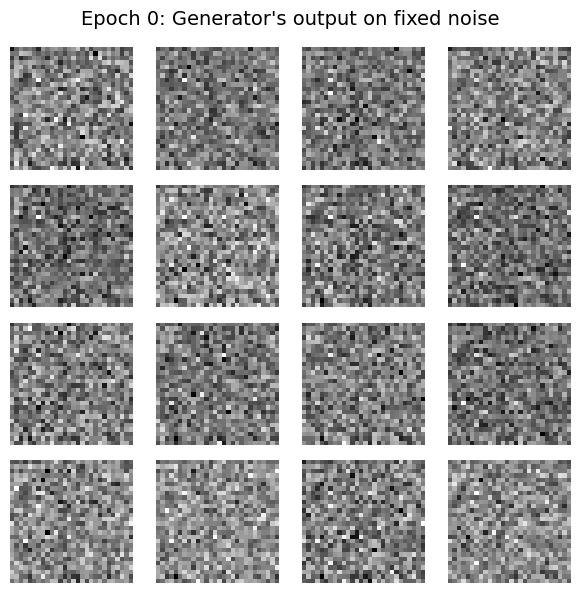

In [8]:
def show_generated_samples(epoch):
    """Generate 16 fake images from fixed_noise and display in a 4x4 grid."""

    # Switch G to eval mode (disables dropout, etc.)
    G.eval()

    with torch.no_grad():            # don't track gradients (saves memory, faster)
        fake_imgs = G(fixed_noise)   # shape: [16, 1, 28, 28]

    # Move back to CPU and un-normalize from [-1, 1] to [0, 1]
    fake_imgs = (fake_imgs.cpu() + 1) / 2

    # Plot 4x4 grid
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_imgs[i].squeeze(), cmap="gray")
        ax.axis("off")
    plt.suptitle(f"Epoch {epoch}: Generator's output on fixed noise", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Switch back to training mode
    G.train()


# Test it BEFORE training — show what the untrained G produces
print("Untrained Generator output (should be pure noise / static):")
show_generated_samples(epoch=0)

🎬 Starting GAN training for 10 epochs
   (469 batches per epoch on Tesla T4)

Epoch [1/10] Batch [  0/469] | D loss: 1.3709 | G loss: 0.6932 | D(real): 0.507 | D(fake): 0.499
Epoch [1/10] Batch [100/469] | D loss: 1.3561 | G loss: 0.8350 | D(real): 0.609 | D(fake): 0.566
Epoch [1/10] Batch [200/469] | D loss: 1.4390 | G loss: 3.1049 | D(real): 0.994 | D(fake): 0.740
Epoch [1/10] Batch [300/469] | D loss: 0.3117 | G loss: 3.8833 | D(real): 0.902 | D(fake): 0.175
Epoch [1/10] Batch [400/469] | D loss: 0.4222 | G loss: 2.3042 | D(real): 0.772 | D(fake): 0.066
  ✓ Epoch 1/10 done in 14.0s | Avg G loss: 2.0308 | Avg D loss: 0.7998



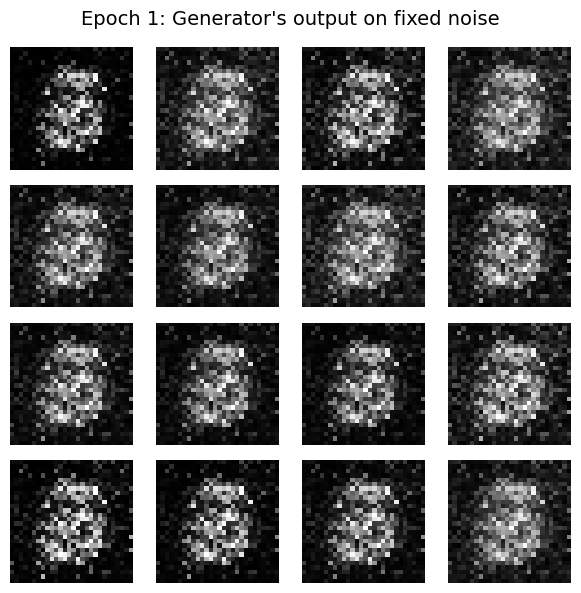

Epoch [2/10] Batch [  0/469] | D loss: 1.2618 | G loss: 1.4219 | D(real): 0.451 | D(fake): 0.049
Epoch [2/10] Batch [100/469] | D loss: 1.9514 | G loss: 5.8483 | D(real): 0.904 | D(fake): 0.787
Epoch [2/10] Batch [200/469] | D loss: 0.2450 | G loss: 2.5216 | D(real): 0.953 | D(fake): 0.171
Epoch [2/10] Batch [300/469] | D loss: 0.3453 | G loss: 3.4871 | D(real): 0.964 | D(fake): 0.245
Epoch [2/10] Batch [400/469] | D loss: 0.3628 | G loss: 2.8545 | D(real): 0.804 | D(fake): 0.059
  ✓ Epoch 2/10 done in 13.7s | Avg G loss: 3.3231 | Avg D loss: 0.5432



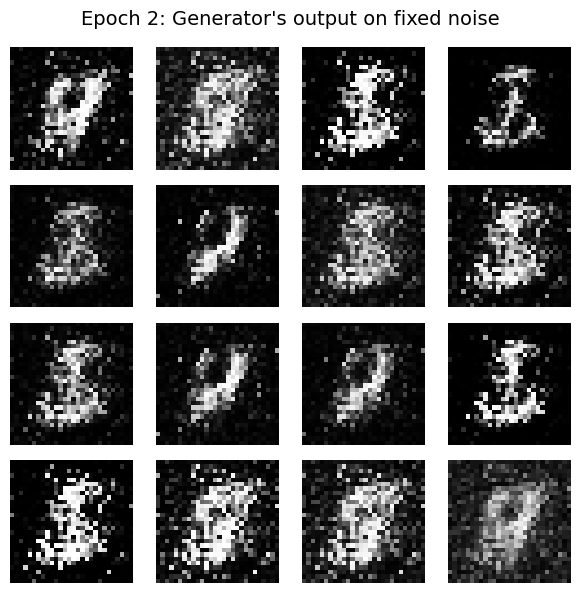

Epoch [3/10] Batch [  0/469] | D loss: 0.2790 | G loss: 3.3047 | D(real): 0.917 | D(fake): 0.155
Epoch [3/10] Batch [100/469] | D loss: 0.6321 | G loss: 3.9741 | D(real): 0.940 | D(fake): 0.378
Epoch [3/10] Batch [200/469] | D loss: 0.3452 | G loss: 3.9975 | D(real): 0.893 | D(fake): 0.140
Epoch [3/10] Batch [300/469] | D loss: 0.3824 | G loss: 3.1049 | D(real): 0.818 | D(fake): 0.010
Epoch [3/10] Batch [400/469] | D loss: 0.2342 | G loss: 3.5258 | D(real): 0.933 | D(fake): 0.113
  ✓ Epoch 3/10 done in 13.5s | Avg G loss: 3.7003 | Avg D loss: 0.4107

Epoch [4/10] Batch [  0/469] | D loss: 0.3112 | G loss: 3.5774 | D(real): 0.862 | D(fake): 0.040
Epoch [4/10] Batch [100/469] | D loss: 0.4820 | G loss: 2.3645 | D(real): 0.799 | D(fake): 0.043
Epoch [4/10] Batch [200/469] | D loss: 0.6241 | G loss: 2.8699 | D(real): 0.764 | D(fake): 0.037
Epoch [4/10] Batch [300/469] | D loss: 0.4497 | G loss: 2.8664 | D(real): 0.869 | D(fake): 0.207
Epoch [4/10] Batch [400/469] | D loss: 0.4936 | G loss:

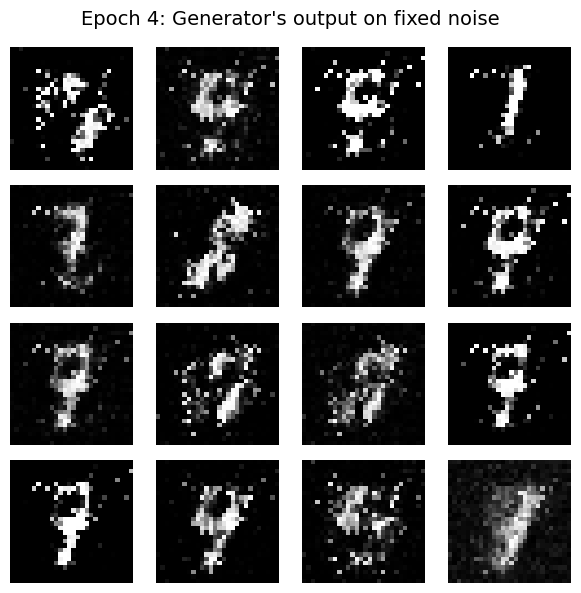

Epoch [5/10] Batch [  0/469] | D loss: 0.3968 | G loss: 2.6937 | D(real): 0.866 | D(fake): 0.144
Epoch [5/10] Batch [100/469] | D loss: 0.4796 | G loss: 3.5497 | D(real): 0.916 | D(fake): 0.267
Epoch [5/10] Batch [200/469] | D loss: 0.7500 | G loss: 4.6387 | D(real): 0.968 | D(fake): 0.379
Epoch [5/10] Batch [300/469] | D loss: 0.3600 | G loss: 2.7583 | D(real): 0.913 | D(fake): 0.179
Epoch [5/10] Batch [400/469] | D loss: 0.4790 | G loss: 2.6279 | D(real): 0.860 | D(fake): 0.210
  ✓ Epoch 5/10 done in 13.7s | Avg G loss: 2.7406 | Avg D loss: 0.5075

Epoch [6/10] Batch [  0/469] | D loss: 0.4864 | G loss: 2.0921 | D(real): 0.855 | D(fake): 0.196
Epoch [6/10] Batch [100/469] | D loss: 0.6536 | G loss: 2.5981 | D(real): 0.859 | D(fake): 0.279
Epoch [6/10] Batch [200/469] | D loss: 0.5404 | G loss: 2.4121 | D(real): 0.755 | D(fake): 0.067
Epoch [6/10] Batch [300/469] | D loss: 0.3964 | G loss: 3.1656 | D(real): 0.888 | D(fake): 0.178
Epoch [6/10] Batch [400/469] | D loss: 0.4965 | G loss:

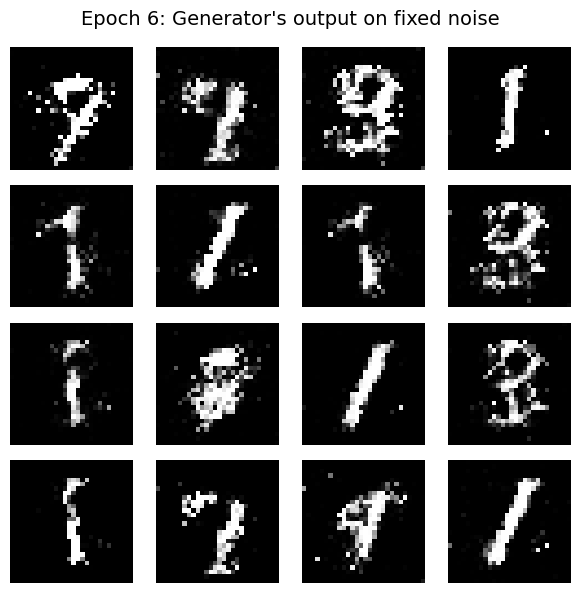

Epoch [7/10] Batch [  0/469] | D loss: 0.5795 | G loss: 2.0865 | D(real): 0.784 | D(fake): 0.127
Epoch [7/10] Batch [100/469] | D loss: 0.5886 | G loss: 2.1805 | D(real): 0.796 | D(fake): 0.159
Epoch [7/10] Batch [200/469] | D loss: 0.4647 | G loss: 1.1288 | D(real): 0.810 | D(fake): 0.132
Epoch [7/10] Batch [300/469] | D loss: 0.4712 | G loss: 3.0003 | D(real): 0.863 | D(fake): 0.177
Epoch [7/10] Batch [400/469] | D loss: 0.6111 | G loss: 3.2982 | D(real): 0.898 | D(fake): 0.293
  ✓ Epoch 7/10 done in 13.5s | Avg G loss: 2.3118 | Avg D loss: 0.5732

Epoch [8/10] Batch [  0/469] | D loss: 0.6837 | G loss: 1.7289 | D(real): 0.774 | D(fake): 0.200
Epoch [8/10] Batch [100/469] | D loss: 0.4938 | G loss: 2.1158 | D(real): 0.878 | D(fake): 0.227
Epoch [8/10] Batch [200/469] | D loss: 0.5479 | G loss: 1.7747 | D(real): 0.812 | D(fake): 0.173
Epoch [8/10] Batch [300/469] | D loss: 0.4975 | G loss: 1.4637 | D(real): 0.835 | D(fake): 0.181
Epoch [8/10] Batch [400/469] | D loss: 0.6101 | G loss:

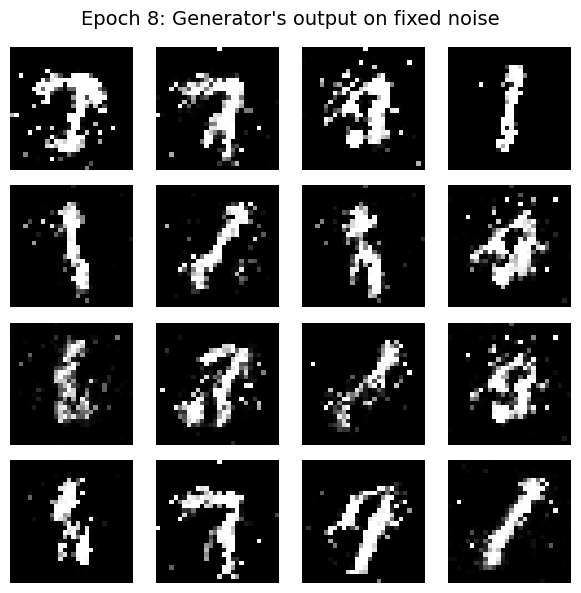

Epoch [9/10] Batch [  0/469] | D loss: 0.9998 | G loss: 1.3464 | D(real): 0.592 | D(fake): 0.080
Epoch [9/10] Batch [100/469] | D loss: 0.6547 | G loss: 1.7849 | D(real): 0.727 | D(fake): 0.111
Epoch [9/10] Batch [200/469] | D loss: 0.7418 | G loss: 3.4974 | D(real): 0.894 | D(fake): 0.347
Epoch [9/10] Batch [300/469] | D loss: 0.5436 | G loss: 2.1706 | D(real): 0.796 | D(fake): 0.180
Epoch [9/10] Batch [400/469] | D loss: 0.7433 | G loss: 2.8110 | D(real): 0.876 | D(fake): 0.374
  ✓ Epoch 9/10 done in 13.5s | Avg G loss: 2.1155 | Avg D loss: 0.6574

Epoch [10/10] Batch [  0/469] | D loss: 1.0285 | G loss: 0.7945 | D(real): 0.539 | D(fake): 0.070
Epoch [10/10] Batch [100/469] | D loss: 0.6340 | G loss: 1.7799 | D(real): 0.739 | D(fake): 0.137
Epoch [10/10] Batch [200/469] | D loss: 0.7227 | G loss: 1.9410 | D(real): 0.797 | D(fake): 0.274
Epoch [10/10] Batch [300/469] | D loss: 0.7760 | G loss: 1.5707 | D(real): 0.660 | D(fake): 0.102
Epoch [10/10] Batch [400/469] | D loss: 0.7396 | G 

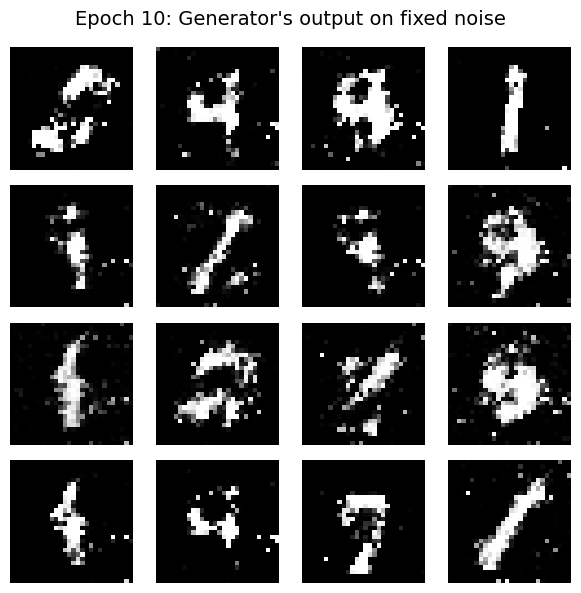


🎉 Training complete in 137.8s (2.3 min)


In [9]:
import time

num_epochs = 10
all_G_losses = []
all_D_losses = []

print(f"🎬 Starting GAN training for {num_epochs} epochs")
print(f"   ({len(train_loader)} batches per epoch on Tesla T4)\n")

start = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()

    # Run one full epoch of training
    G_losses_epoch, D_losses_epoch = train_one_epoch(epoch, num_epochs)

    all_G_losses.extend(G_losses_epoch)
    all_D_losses.extend(D_losses_epoch)

    epoch_time = time.time() - epoch_start
    avg_G_loss = sum(G_losses_epoch) / len(G_losses_epoch)
    avg_D_loss = sum(D_losses_epoch) / len(D_losses_epoch)
    print(f"  ✓ Epoch {epoch+1}/{num_epochs} done in {epoch_time:.1f}s | "
          f"Avg G loss: {avg_G_loss:.4f} | Avg D loss: {avg_D_loss:.4f}\n")

    # Show generated samples every 2 epochs (and after the first one)
    if (epoch + 1) % 2 == 0 or epoch == 0:
        show_generated_samples(epoch=epoch+1)

total_time = time.time() - start
print(f"\n🎉 Training complete in {total_time:.1f}s ({total_time/60:.1f} min)")

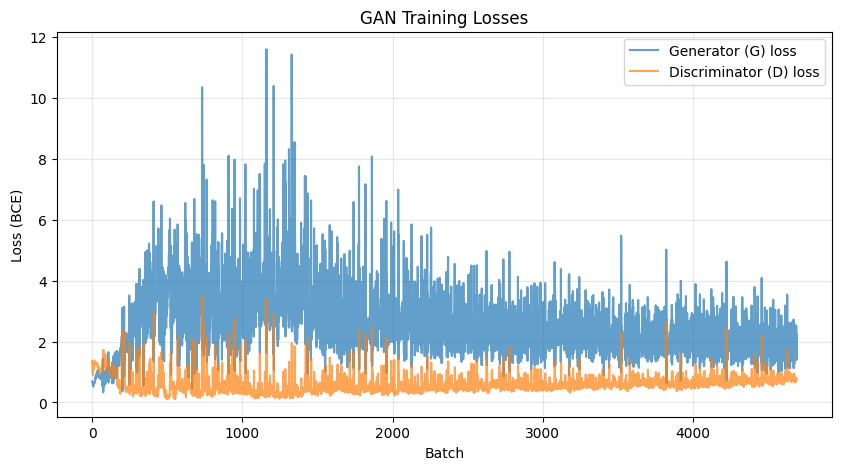

Final G loss: 1.5446
Final D loss: 0.7815
Avg G loss (last epoch): 1.9451
Avg D loss (last epoch): 0.7543


In [10]:
plt.figure(figsize=(10, 5))
plt.plot(all_G_losses, label="Generator (G) loss", alpha=0.7)
plt.plot(all_D_losses, label="Discriminator (D) loss", alpha=0.7)
plt.xlabel("Batch")
plt.ylabel("Loss (BCE)")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final G loss: {all_G_losses[-1]:.4f}")
print(f"Final D loss: {all_D_losses[-1]:.4f}")
print(f"Avg G loss (last epoch): {sum(all_G_losses[-469:]) / 469:.4f}")
print(f"Avg D loss (last epoch): {sum(all_D_losses[-469:]) / 469:.4f}")

🎨 Current Generator output (after full training):


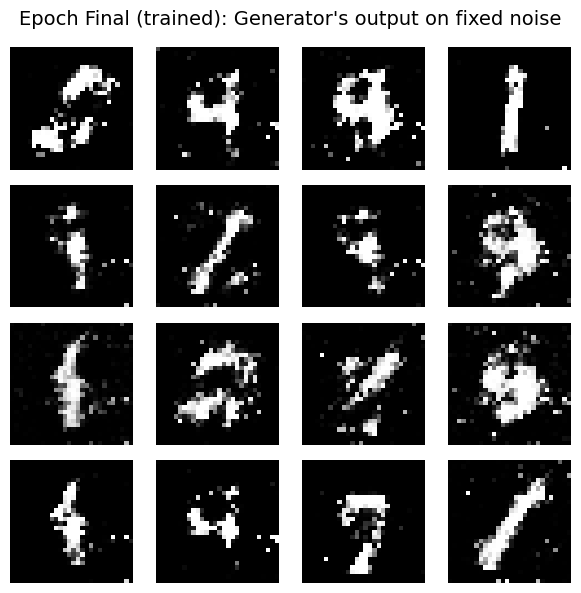

In [11]:
# Generate fresh samples from the trained Generator
print("🎨 Current Generator output (after full training):")
show_generated_samples(epoch="Final (trained)")